# K-Means


**k range**: 5 to 10


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import math
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import normalize, Normalizer, FunctionTransformer
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.pipeline import Pipeline
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from wordcloud import WordCloud
from collections import Counter
from matplotlib import cm
import umap as umap_lib
import warnings
import os
import random
import services.utils as ut
import services.model as md_module

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TRANSFORMERS_VERBOSITY'] = 'error'
np.random.seed(42)
random.seed(42)
print('Libraries loaded.')
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


Libraries loaded.


## 1. Load Data

In [30]:
data_df = ut.load_data('customer_support_tickets.csv')
data_df = data_df.drop_duplicates(subset=['Ticket Description'], keep='first').reset_index(drop=True)
data_df['text'] = data_df['Ticket Description'].fillna('')
if data_df is not None:
    print('Data loaded successfully')
print(data_df.head())

Data loaded successfully
   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   

## 2. Preprocessing

In [31]:
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\{.*?\}', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\b[a-zA-Z]{1,2}\b', '', text)
    return text

data_df['clean_text'] = data_df['text'].apply(clean_text)
data_df['clean_text'].head()

0     having  issue with the  please assist\n\nyour...
1     having  issue with the  please assist\n\n you...
2     facing  problem with   the   not turning   wa...
3     having  issue with the  please assist\n\n you...
4     having  issue with the  please assist\n\n\nno...
Name: clean_text, dtype: object

In [32]:
custom_words = {
    'please', 'help', 'assist', 'support', 'thanks', 'thank', 'soon', 'mentioned',
    'im', 'ive', 'us', 'would', 'could', 'need', 'want', 'trying',
    'tried', 'check', 'checked', 'make', 'made', 'get', 'getting', 'also',
    'use', 'using', 'used', 'thing', 'something', 'anything', 'everything',
    'way', 'time', 'issue', 'problem', 'request',
    'work', 'working', 'fine', 'available', 'recent', 'recently', 'facing', 'doe',
    'noticed', 'happening', 'started', 'happen', 'different', 'steps', 'did',
    'regards', 'already', 'multiple', 'last', 'times', 'followed', 'reviewed',
    'specific', 'possible', 'related', 'new', 'old', 'find', 'try', 'trying', 'say', 'mean',
    'name', 'email', 'price', 'one', 'add', 'note', 'may', 'dont', 'know', 'sure',
    'changes', 'performed', 'properly', 'original', 'like', 'similar', 'reported', 'doesnt',
    'sometimes', 'acts', 'works', 'ensure', 'desired', 'action', 'remains', 'life', 'seems',
    'might', 'guide', 'much', 'others', 'heavily', 'daily', 'task',
    'affecting', 'assistance', 'hoping', 'persists', 'didnt',
    'option', 'perform', 'recommendation', 'information', 'official',
    'solution', 'provide', 'making', 'user', 'customer', 'item', 'device',
    'far', 'luck', 'contact', 'contacted', 'occurring'
}
custom_words_lemma = set([lemmatizer.lemmatize(w) for w in custom_words])

def preprocess(text):
    tokens = word_tokenize(text)
    processed_tokens = []
    for word in tokens:
        lemma = lemmatizer.lemmatize(word)
        if lemma not in stop_words and lemma not in custom_words_lemma and len(lemma) > 2:
            processed_tokens.append(lemma)
    return ' '.join(processed_tokens)

data_df['processed_text'] = data_df['clean_text'].apply(preprocess)

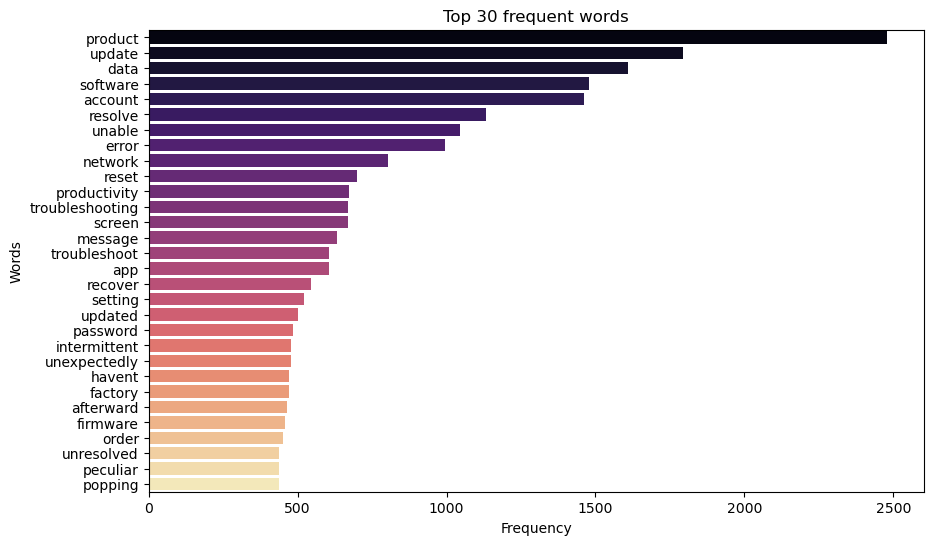

In [33]:
text_data = data_df['processed_text'].astype(str)
all_words = ' '.join(text_data).lower().split()
common_words = Counter(all_words).most_common(30)
words, counts = zip(*common_words)

plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette='magma', legend=False)
plt.title('Top 30 frequent words')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()

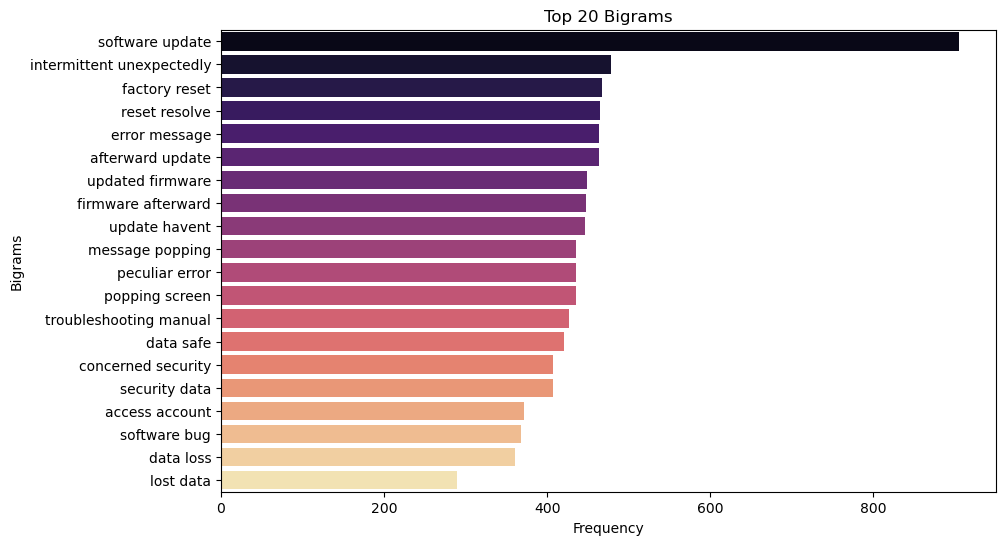

In [34]:
vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words='english')
x = vectorizer.fit_transform(data_df['processed_text'])
word_counts = x.sum(axis=0).A1
words = vectorizer.get_feature_names_out()
word_freq = list(zip(words, word_counts))
word_freq = sorted(word_freq, key=lambda x: x[1], reverse=True)[:20]
words, counts = zip(*word_freq)

plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette='magma')
plt.title('Top 20 Bigrams')
plt.xlabel('Frequency')
plt.ylabel('Bigrams')
plt.show()

In [35]:
ut.save_data(data_df, 'cleaned_data.csv')

## 3. Text Representation

### 3.1 TF-IDF

In [36]:
def nlp_cleaner(text_list):
    results = []
    for text in text_list:
        cleaned = clean_text(text)
        processed = preprocess(cleaned)
        results.append(processed)
    return results

In [37]:
tfidf = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), min_df=5, max_df=0.7)
X = tfidf.fit_transform(data_df['processed_text'])

In [38]:
tfidf__preprocessing_pipeline = Pipeline([
    ('cleaner', FunctionTransformer(nlp_cleaner, validate=False)),
    ('tfidf', TfidfVectorizer(max_features=1000, ngram_range=(1, 2), min_df=5, max_df=0.7))
])

### 3.2 Sentence Embeddings

In [39]:
def clean_for_embeddings(text):
    text = text.lower()
    text = re.sub(r'\{.*?\}', ' ', text)
    text = re.sub(r'http\S+', ' ', text)
    text = re.sub(r"i'?m having an issue with.*?please assist\.?", ' ', text)
    text = re.sub(r'please assist\.?', ' ', text)
    text = re.sub(r'\b(id|created_at|product|price)\b', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [40]:
data_df['embedding_text'] = data_df['text'].apply(clean_for_embeddings)

In [41]:
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10089.29it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [42]:
embeddings = model.encode(data_df['embedding_text'].tolist(), show_progress_bar=True)

Batches: 100%|██████████| 253/253 [00:07<00:00, 35.11it/s]


In [43]:
embeddings = normalize(embeddings)

In [44]:
print(cosine_similarity([embeddings[0]], [embeddings[1]]))
print(cosine_similarity([embeddings[2]], [embeddings[5]]))

[[0.33734772]]
[[0.6662934]]


In [45]:
def nlp_cleaner_embeddings(text_list):
    results = []
    for text in text_list:
        cleaned = clean_for_embeddings(text)
        results.append(cleaned)
    return results

In [46]:
embedding_preprocessing_pipeline = Pipeline([
    ('cleaner', FunctionTransformer(nlp_cleaner_embeddings, validate=False)),
    ('embeddings', md_module.SentenceEmbeddingTransformer(model_name='all-MiniLM-L6-v2')),
    ('normalize', Normalizer())
])

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 14576.82it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## 4. K-Means Clustering



### 4.0 Baseline: K-Means on Raw Features 


Baseline K-Means (no dim reduction):
  k=5 | TF-IDF  sil=0.0433       | Embed   sil=0.0957
  k=6 | TF-IDF  sil=0.0507       | Embed   sil=0.0997
  k=7 | TF-IDF  sil=0.0577       | Embed   sil=0.1000
  k=8 | TF-IDF  sil=0.0635       | Embed   sil=0.1086
  k=9 | TF-IDF  sil=0.0718       | Embed   sil=0.1168
  k=10 | TF-IDF  sil=0.0791       | Embed   sil=0.1226


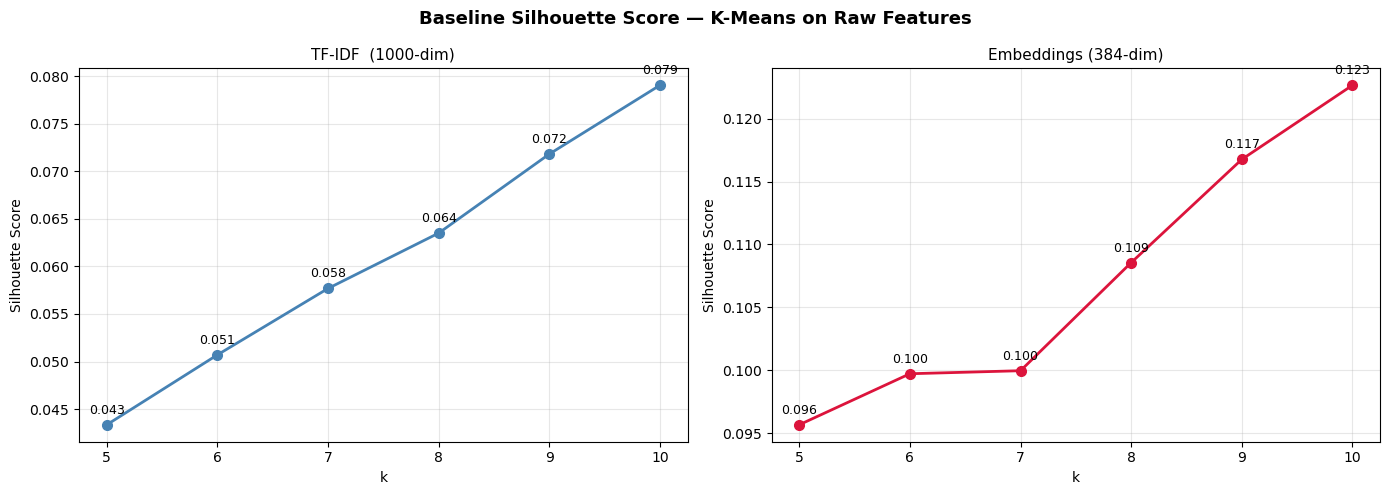

In [47]:
# Baseline: K-Means on raw features without any dimensionality reduction
X_tfidf_raw = normalize(X).toarray()   
X_embed_raw = embeddings               

K_RANGE_BASE = range(5, 11)
sil_base_tfidf, sil_base_embed = [], []

print('Baseline K-Means (no dim reduction):')
for k in K_RANGE_BASE:
    lbl_t = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_tfidf_raw)
    lbl_e = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_embed_raw)
    sil_base_tfidf.append(silhouette_score(X_tfidf_raw, lbl_t))
    sil_base_embed.append(silhouette_score(X_embed_raw, lbl_e))
    print(f'  k={k} | TF-IDF  sil={sil_base_tfidf[-1]:.4f}'
          f'       | Embed   sil={sil_base_embed[-1]:.4f}')

k_list_base = list(K_RANGE_BASE)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Baseline Silhouette Score — K-Means on Raw Features',
             fontsize=13, fontweight='bold')
for ax, sil, name, color in [
    (axes[0], sil_base_tfidf, 'TF-IDF  (1000-dim)', 'steelblue'),
    (axes[1], sil_base_embed, 'Embeddings (384-dim)', 'crimson'),
]:
    ax.plot(k_list_base, sil, 'o-', color=color, linewidth=2, markersize=7)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('k'); ax.set_ylabel('Silhouette Score')
    for k, s in zip(k_list_base, sil):
        ax.annotate(f'{s:.3f}', (k, s), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=9)
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### 4.1 Dimensionality Reduction (PCA for TF-IDF, UMAP for Embeddings)
#### as the performance of TF-IDF and embedding are not good, I want to use PCA and UMAP to reduce dimensions before k-means cluster


In [48]:
X_tfidf_norm = normalize(X)

# PCA-100 for TF-IDF clustering
pca100 = PCA(n_components=100, random_state=42)
X_tfidf_pca = pca100.fit_transform(X_tfidf_norm.toarray())
print(f'PCA-100 variance explained: {pca100.explained_variance_ratio_.sum()*100:.1f}%')

# PCA-2D for TF-IDF visualisation
pca2d = PCA(n_components=2, random_state=42)
X_tfidf_2d = pca2d.fit_transform(X_tfidf_norm.toarray())
print(f'TF-IDF PCA-2D shape: {X_tfidf_2d.shape}')

# UMAP-20 for Embeddings clustering (normalize for cosine-distance clustering)
reducer20 = umap_lib.UMAP(n_components=20, n_neighbors=30, min_dist=0.0,
                           metric='cosine', random_state=42)
X_embed_umap = normalize(reducer20.fit_transform(embeddings))
print(f'Embeddings UMAP-20 shape: {X_embed_umap.shape}')

# UMAP-2D for Embeddings visualisation (NO normalize — keeps spatial layout)
reducer2d = umap_lib.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                           metric='cosine', random_state=42)
X_embed_2d = reducer2d.fit_transform(embeddings)
print(f'Embeddings UMAP-2D shape: {X_embed_2d.shape}')


PCA-100 variance explained: 64.6%
TF-IDF PCA-2D shape: (8077, 2)
Embeddings UMAP-20 shape: (8077, 20)
Embeddings UMAP-2D shape: (8077, 2)


### 4.2 K Sweep (from 5 to 10)

In [49]:
K_RANGE = range(5, 11)
inertia_tfidf, inertia_embed = [], []
sil_tfidf, sil_embed = [], []

for k in K_RANGE:
    km_t = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl_t = km_t.fit_predict(X_tfidf_pca)
    inertia_tfidf.append(km_t.inertia_)
    sil_tfidf.append(silhouette_score(X_tfidf_pca, lbl_t))

    km_e = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl_e = km_e.fit_predict(X_embed_umap)
    inertia_embed.append(km_e.inertia_)
    sil_embed.append(silhouette_score(X_embed_umap, lbl_e))

    print(f'k={k} | TF-IDF: inertia={inertia_tfidf[-1]:8.1f}, sil={sil_tfidf[-1]:.4f}'
          f' | Embed: inertia={inertia_embed[-1]:8.1f}, sil={sil_embed[-1]:.4f}')

k_list = list(K_RANGE)
best_k_tfidf = k_list[np.argmax(sil_tfidf)]
best_k_embed = k_list[np.argmax(sil_embed)]
print(f'\nBest k — TF-IDF: {best_k_tfidf}  Sil={max(sil_tfidf):.4f}')
print(f'Best k — Embeddings: {best_k_embed}  Sil={max(sil_embed):.4f}')


k=5 | TF-IDF: inertia=  4526.3, sil=0.0918 | Embed: inertia=   414.7, sil=0.5884
k=6 | TF-IDF: inertia=  4375.1, sil=0.0681 | Embed: inertia=   375.0, sil=0.6048
k=7 | TF-IDF: inertia=  4262.4, sil=0.0987 | Embed: inertia=   348.3, sil=0.5825
k=8 | TF-IDF: inertia=  4176.6, sil=0.1183 | Embed: inertia=   294.0, sil=0.6461
k=9 | TF-IDF: inertia=  4030.2, sil=0.1211 | Embed: inertia=   273.4, sil=0.6458
k=10 | TF-IDF: inertia=  3919.2, sil=0.1377 | Embed: inertia=   234.9, sil=0.6819

Best k — TF-IDF: 10  Sil=0.1377
Best k — Embeddings: 10  Sil=0.6819


### 4.3 Elbow & Silhouette Plots

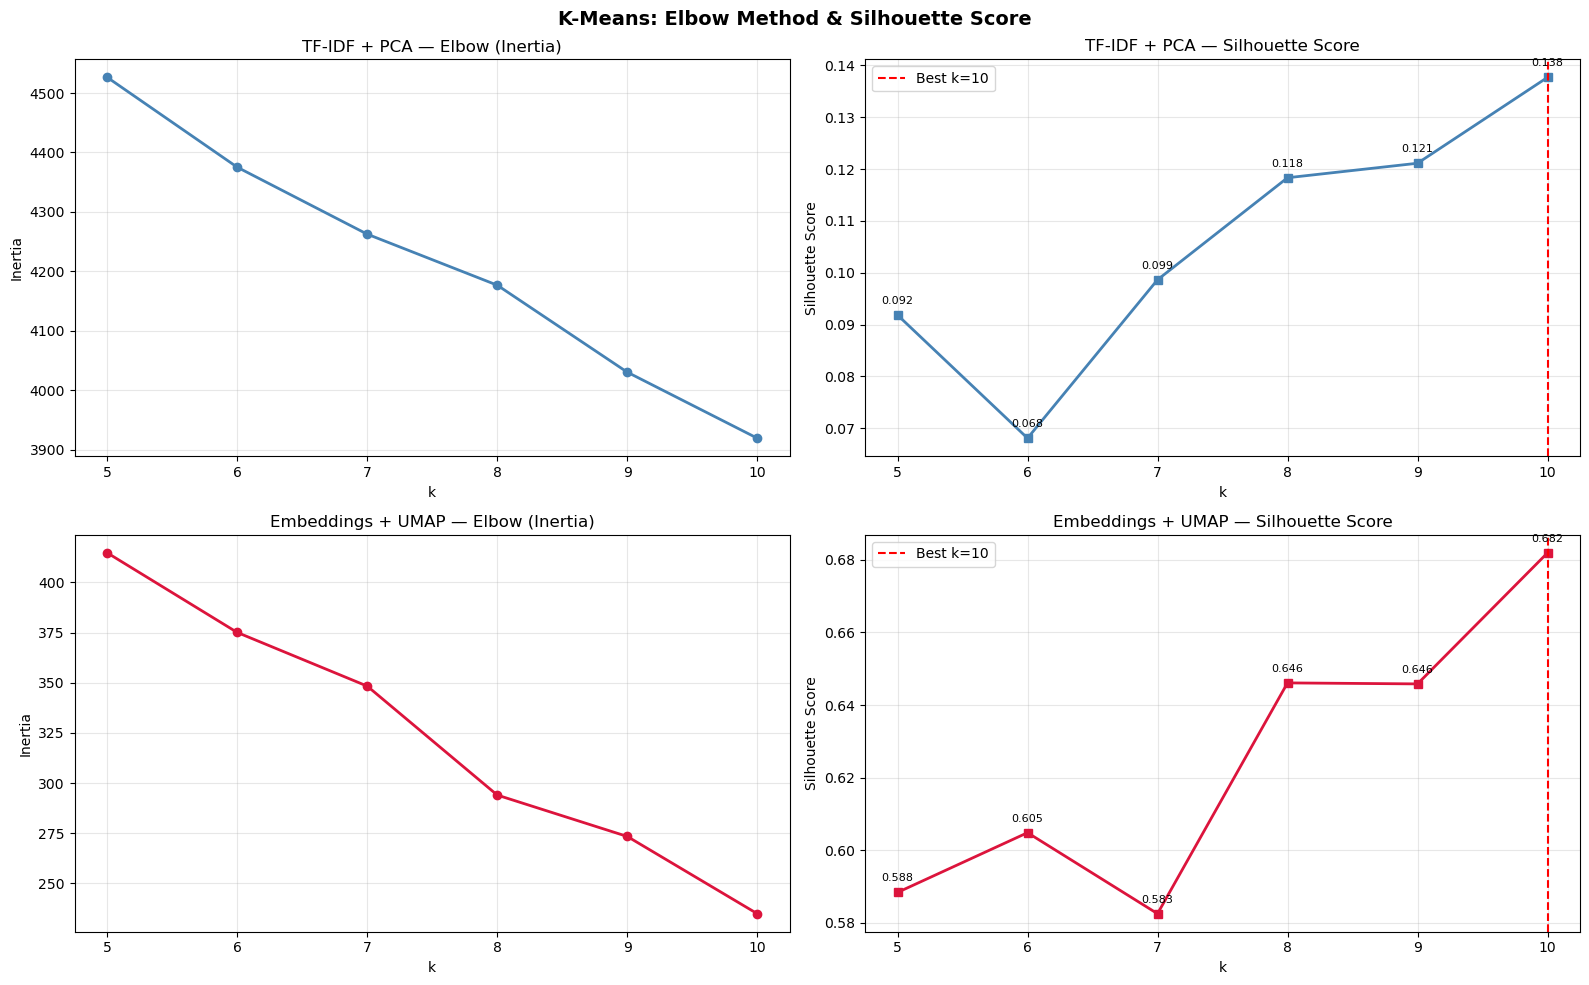

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('K-Means: Elbow Method & Silhouette Score', fontsize=14, fontweight='bold')

for row, (inertia, sil, best_k, name, color) in enumerate([
    (inertia_tfidf, sil_tfidf, best_k_tfidf, 'TF-IDF + PCA',      'steelblue'),
    (inertia_embed, sil_embed, best_k_embed, 'Embeddings + UMAP',  'crimson'),
]):
    axes[row, 0].plot(k_list, inertia, 'o-', color=color, linewidth=2)
    axes[row, 0].set_title(f'{name} — Elbow (Inertia)')
    axes[row, 0].set_xlabel('k'); axes[row, 0].set_ylabel('Inertia')
    axes[row, 0].grid(alpha=0.3)

    axes[row, 1].plot(k_list, sil, 's-', color=color, linewidth=2)
    axes[row, 1].axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
    axes[row, 1].set_title(f'{name} — Silhouette Score')
    axes[row, 1].set_xlabel('k'); axes[row, 1].set_ylabel('Silhouette Score')
    for k, s in zip(k_list, sil):
        axes[row, 1].annotate(f'{s:.3f}', (k, s), textcoords='offset points', xytext=(0,8), ha='center', fontsize=8)
    axes[row, 1].legend(); axes[row, 1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


### 4.4 Silhouette Analysis at Best k

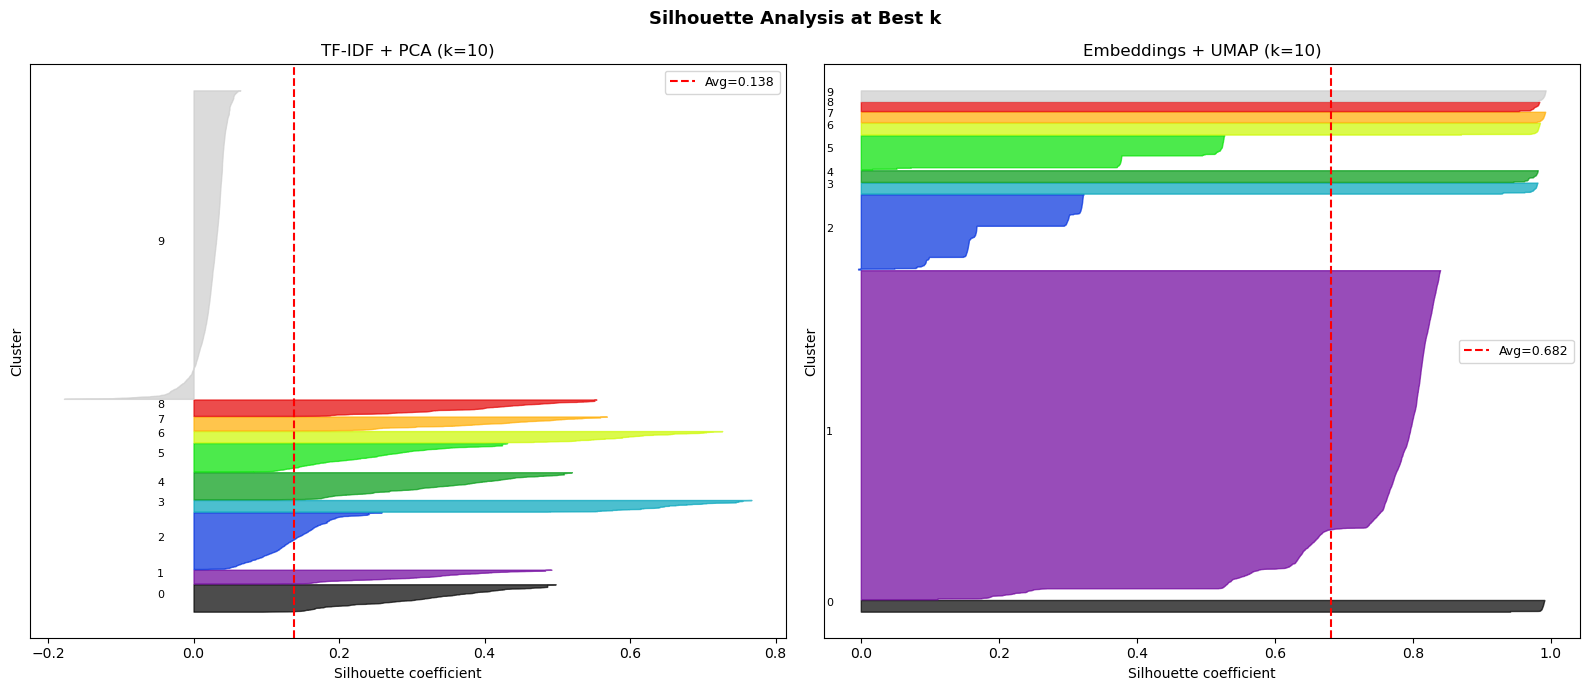

In [51]:
lbl_tfidf_best = KMeans(n_clusters=best_k_tfidf, random_state=42, n_init=10).fit_predict(X_tfidf_pca)
lbl_embed_best = KMeans(n_clusters=best_k_embed, random_state=42, n_init=10).fit_predict(X_embed_umap)

def plot_silhouette(X, labels, title, ax):
    k = len(np.unique(labels))
    sil_vals = silhouette_samples(X, labels)
    y_lower = 10
    colors = cm.nipy_spectral(np.linspace(0, 1, k))
    for i in range(k):
        vals = np.sort(sil_vals[labels == i])
        y_upper = y_lower + len(vals)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                         facecolor=colors[i], edgecolor=colors[i], alpha=0.7)
        ax.text(-0.05, y_lower + 0.5*len(vals), str(i), fontsize=8)
        y_lower = y_upper + 10
    ax.axvline(sil_vals.mean(), color='red', linestyle='--', label=f'Avg={sil_vals.mean():.3f}')
    ax.set_title(title); ax.set_xlabel('Silhouette coefficient')
    ax.set_ylabel('Cluster'); ax.legend(fontsize=9); ax.set_yticks([])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plot_silhouette(X_tfidf_pca,  lbl_tfidf_best, f'TF-IDF + PCA (k={best_k_tfidf})',     axes[0])
plot_silhouette(X_embed_umap, lbl_embed_best, f'Embeddings + UMAP (k={best_k_embed})', axes[1])
plt.suptitle('Silhouette Analysis at Best k', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


### 4.5 2D Cluster Visualisation

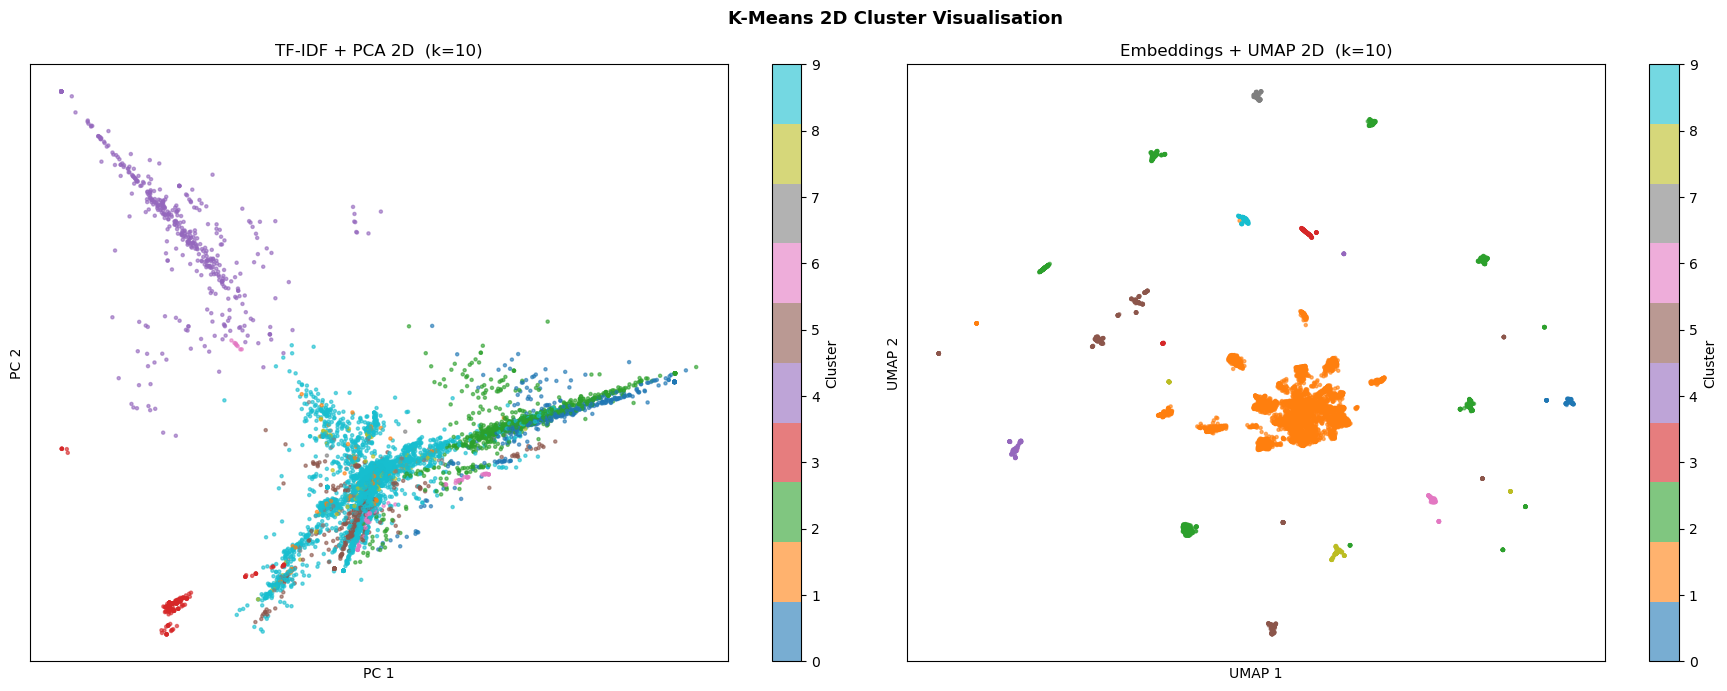

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, X_2d, labels, best_k, name, xlabel, ylabel in [
    (axes[0], X_tfidf_2d, lbl_tfidf_best, best_k_tfidf, 'TF-IDF + PCA',     'PC 1',     'PC 2'),
    (axes[1], X_embed_2d, lbl_embed_best, best_k_embed, 'Embeddings + UMAP', 'UMAP 1', 'UMAP 2'),
]:
    sc = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='tab10', s=5, alpha=0.6)
    ax.set_title(f'{name} 2D  (k={best_k})', fontsize=12)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(sc, ax=ax, label='Cluster')
plt.suptitle('K-Means 2D Cluster Visualisation', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


### 4.6 Cluster Size Distribution

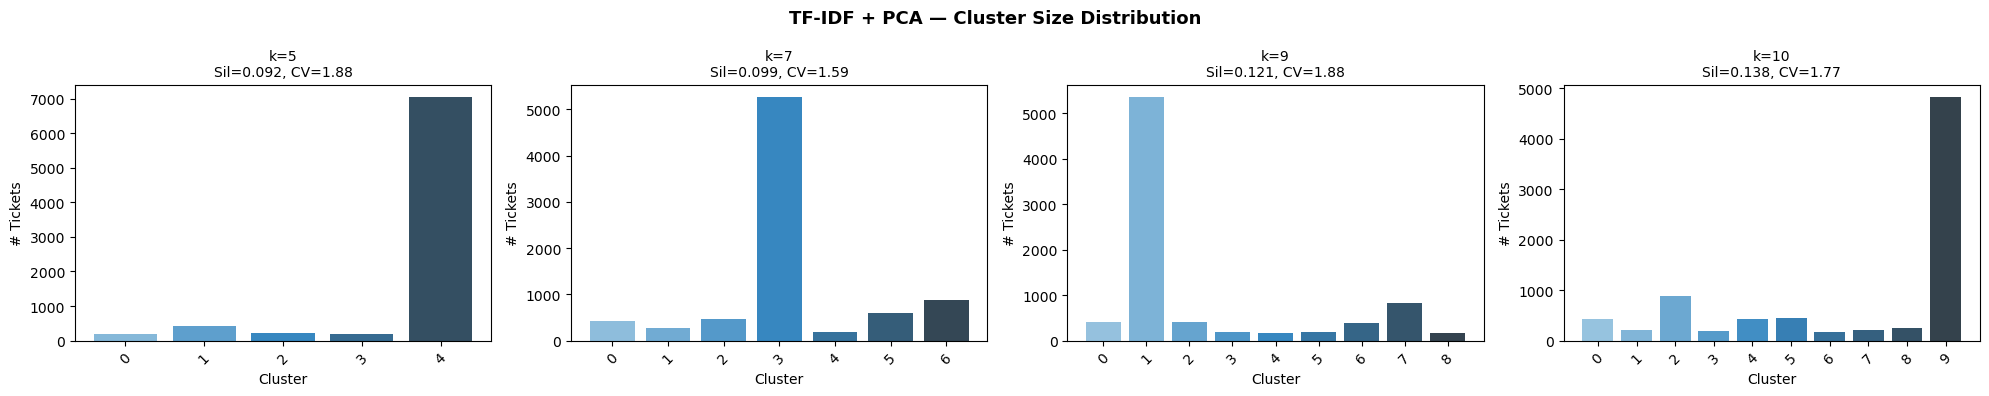

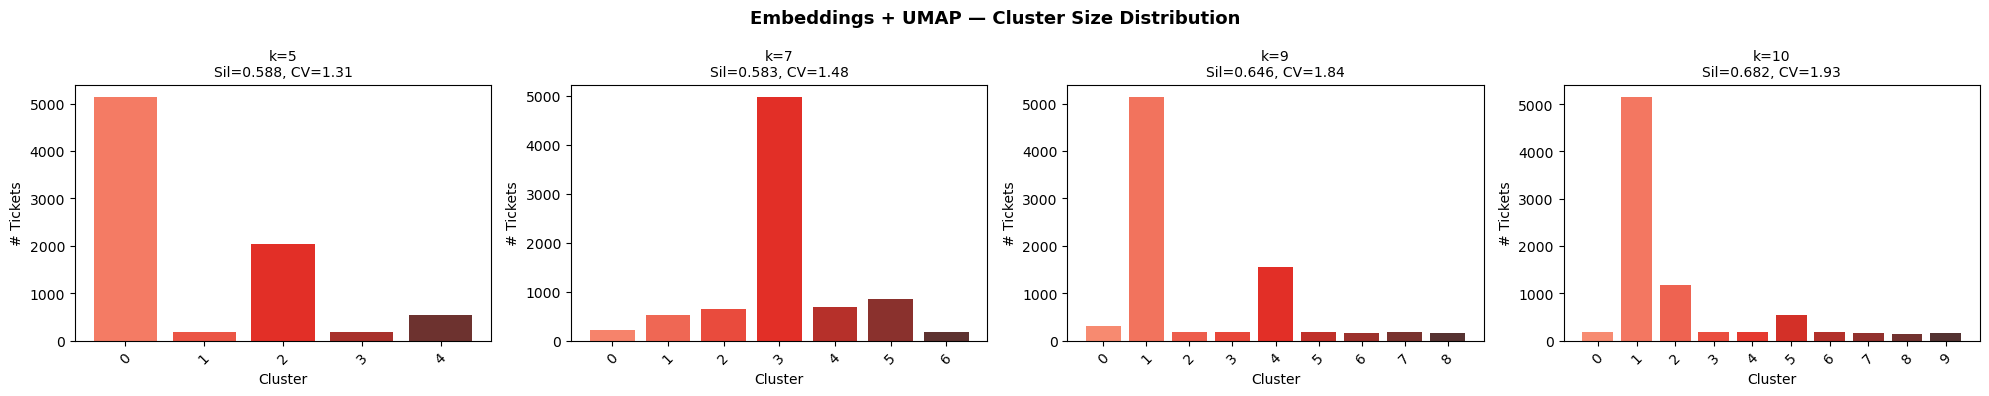

In [53]:
K_SHOW = [5, 7, 9, best_k_tfidf] if best_k_tfidf not in [5, 7, 9] else [5, 6, 8, 10]
K_SHOW_E = [5, 7, 9, best_k_embed] if best_k_embed not in [5, 7, 9] else [5, 6, 8, 10]

for X_c, name, K_VALS, palette in [
    (X_tfidf_pca,  'TF-IDF + PCA',     K_SHOW,   'Blues_d'),
    (X_embed_umap, 'Embeddings + UMAP', K_SHOW_E, 'Reds_d'),
]:
    fig, axes = plt.subplots(1, len(K_VALS), figsize=(20, 4))
    fig.suptitle(f'{name} — Cluster Size Distribution', fontsize=13, fontweight='bold')
    for col, k in enumerate(K_VALS):
        labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_c)
        sizes = pd.Series(labels).value_counts().sort_index()
        sil = silhouette_score(X_c, labels)
        cv  = sizes.std() / sizes.mean()
        axes[col].bar(sizes.index.astype(str), sizes.values, color=sns.color_palette(palette, k))
        axes[col].set_title(f'k={k}\nSil={sil:.3f}, CV={cv:.2f}', fontsize=10)
        axes[col].set_xlabel('Cluster'); axes[col].set_ylabel('# Tickets')
        axes[col].tick_params(axis='x', rotation=45)
    plt.tight_layout(); plt.show()


### 4.7 Top Keywords per Cluster

In [54]:
data_df['cluster_tfidf'] = lbl_tfidf_best
data_df['cluster_embed'] = lbl_embed_best

def get_top_keywords(text_series, n=8):
    words = ' '.join(text_series).split()
    words = [w for w in words if len(w) > 3 and not w.isnumeric()]
    return [w for w, _ in Counter(words).most_common(n)]

for col, name, k in [
    ('cluster_tfidf', 'TF-IDF + PCA',     best_k_tfidf),
    ('cluster_embed', 'Embeddings + UMAP', best_k_embed),
]:
    print('=' * 70)
    print(f'{name}  |  k={k}')
    print('=' * 70)
    for i in range(k):
        docs = data_df[data_df[col] == i]
        kw = get_top_keywords(docs['processed_text'])
        dom = docs['Ticket Subject'].value_counts().index[0] if len(docs) > 0 else 'N/A'
        print(f'  C{i:02d} (n={len(docs):4d}, dom={dom:<30s}): {kw}')
    print()


TF-IDF + PCA  |  k=10
  C00 (n= 430, dom=Product compatibility         ): ['update', 'afterward', 'updated', 'firmware', 'product', 'data', 'account', 'software']
  C01 (n= 218, dom=Payment issue                 ): ['cable', 'adapter', 'peripheral', 'product', 'data', 'recover', 'account', 'deleted']
  C02 (n= 889, dom=Hardware issue                ): ['software', 'update', 'havent', 'product', 'version', 'running', 'latest', 'none']
  C03 (n= 183, dom=Installation support          ): ['account', 'access', 'unable', 'error', 'login', 'correct', 'regain', 'keep']
  C04 (n= 425, dom=Product setup                 ): ['error', 'screen', 'message', 'peculiar', 'popping', 'product', 'account', 'data']
  C05 (n= 447, dom=Battery life                  ): ['reset', 'resolve', 'factory', 'product', 'account', 'data', 'software', 'order']
  C06 (n= 178, dom=Product compatibility         ): ['network', 'connecting', 'resolve', 'wifi', 'home', 'trouble', 'detect', 'although']
  C07 (n= 217, dom=Sof

### 4.8 Word Clouds (Best k — Embeddings)

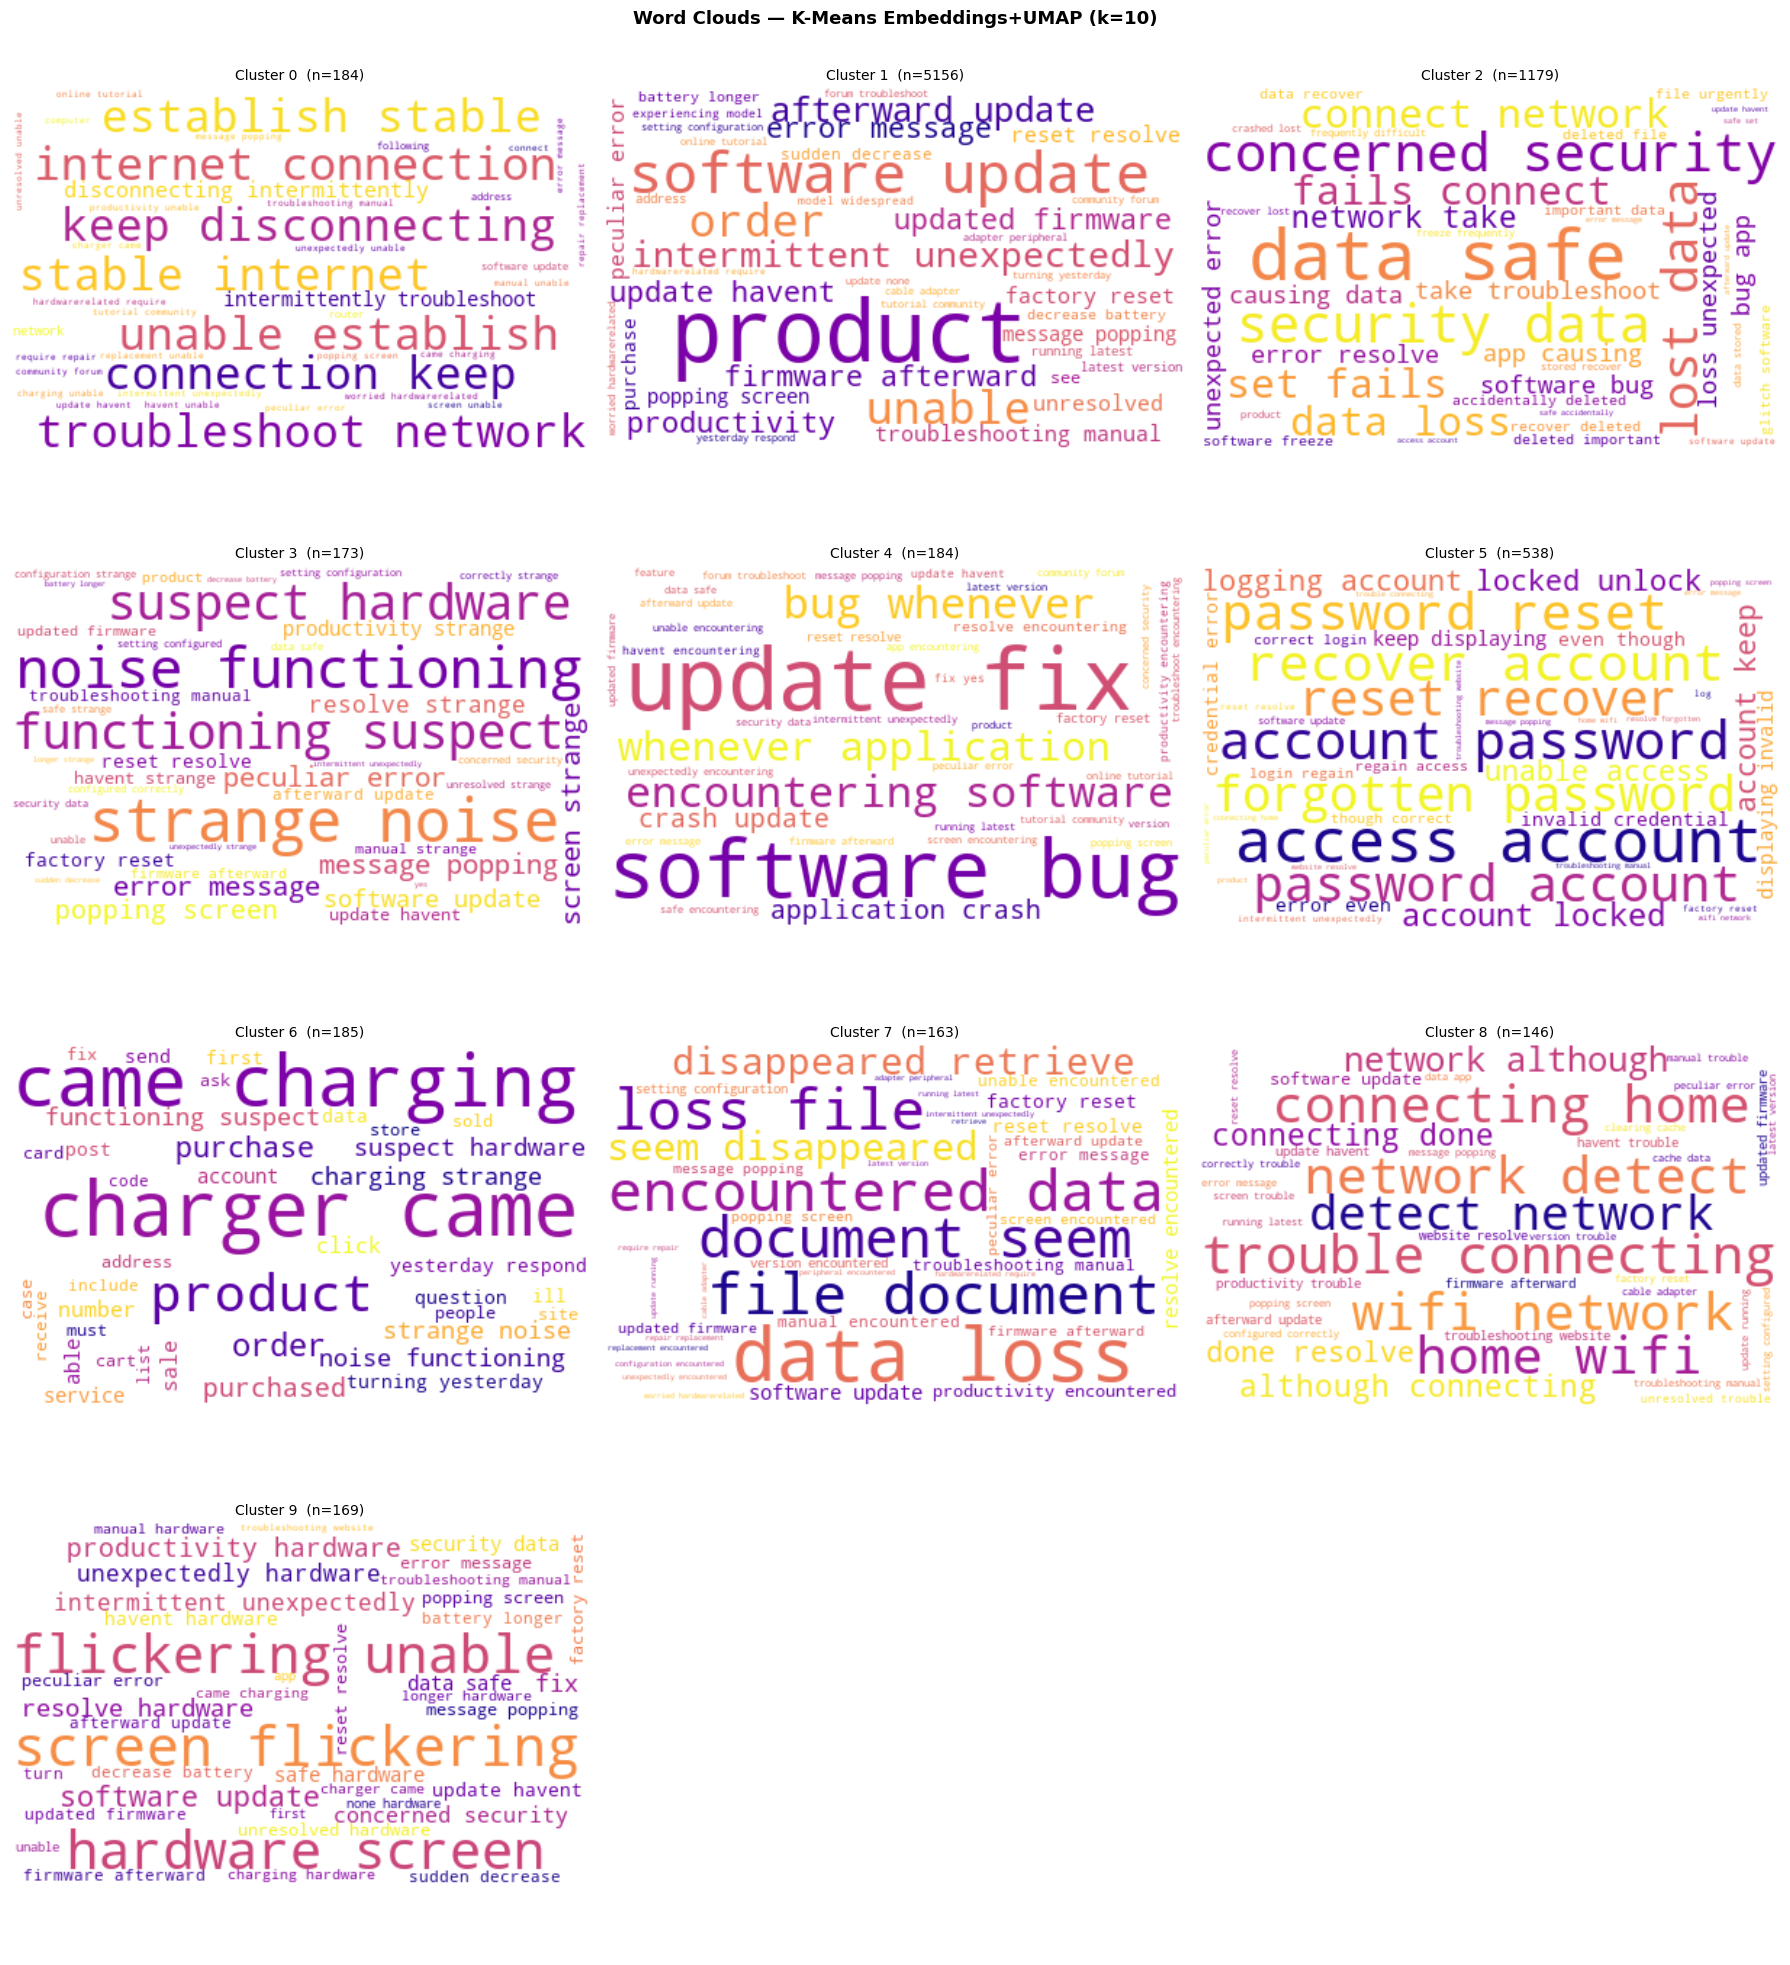

In [55]:
k = best_k_embed
ncols = 3
nrows = math.ceil(k / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5*nrows))
axes = axes.flatten()
for i in range(k):
    docs = data_df[data_df['cluster_embed'] == i]['processed_text']
    text = ' '.join(docs)
    if text.strip():
        wc = WordCloud(width=400, height=250, background_color='white',
                       colormap='plasma', max_words=40).generate(text)
        axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'Cluster {i}  (n={len(docs)})', fontsize=10)
    axes[i].axis('off')
for j in range(k, len(axes)): axes[j].axis('off')
plt.suptitle(f'Word Clouds — K-Means Embeddings+UMAP (k={k})', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 5. Summary

           Method  k  Silhouette  Size CV  Max  Min
     TF-IDF + PCA  5      0.0918    1.884 7058  183
     TF-IDF + PCA  6      0.0681    1.580 5662  178
     TF-IDF + PCA  7      0.0987    1.588 5276  178
     TF-IDF + PCA  8      0.1183    1.631 4898  142
     TF-IDF + PCA  9      0.1211    1.880 5361  161
     TF-IDF + PCA 10      0.1377    1.771 4833  178
Embeddings + UMAP  5      0.5884    1.308 5143  184
Embeddings + UMAP  6      0.6048    1.429 5143  173
Embeddings + UMAP  7      0.5825    1.479 4983  184
Embeddings + UMAP  8      0.6461    1.683 5143  173
Embeddings + UMAP  9      0.6458    1.845 5143  163
Embeddings + UMAP 10      0.6819    1.933 5156  146


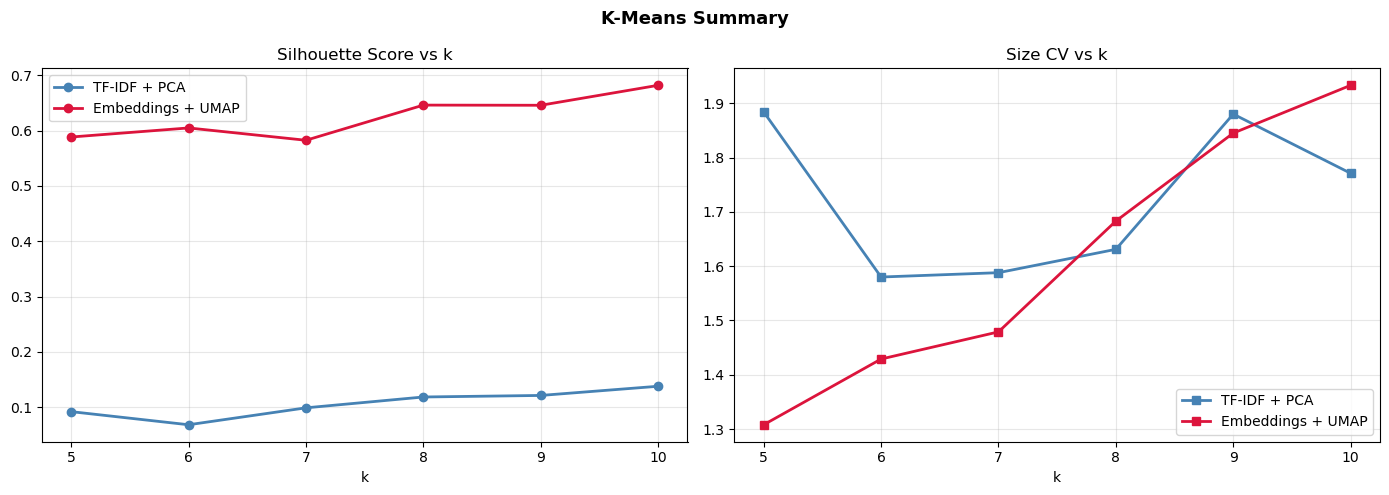

In [56]:
rows = []
for X_c, method in [(X_tfidf_pca, 'TF-IDF + PCA'), (X_embed_umap, 'Embeddings + UMAP')]:
    for k in range(5, 11):
        labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_c)
        sizes = pd.Series(labels).value_counts()
        rows.append({'Method': method, 'k': k,
                     'Silhouette': round(silhouette_score(X_c, labels), 4),
                     'Size CV': round(sizes.std()/sizes.mean(), 3),
                     'Max': int(sizes.max()), 'Min': int(sizes.min())})
summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for method, color in [('TF-IDF + PCA', 'steelblue'), ('Embeddings + UMAP', 'crimson')]:
    sub = summary_df[summary_df['Method'] == method]
    axes[0].plot(sub['k'], sub['Silhouette'], 'o-', label=method, color=color, linewidth=2)
    axes[1].plot(sub['k'], sub['Size CV'],    's-', label=method, color=color, linewidth=2)
axes[0].set_title('Silhouette Score vs k'); axes[0].set_xlabel('k'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title('Size CV vs k');          axes[1].set_xlabel('k'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle('K-Means Summary', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
